### 1. Load data for analysis

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load data from database
conn = sqlite3.connect('../data/weather_data.db')
df = pd.read_sql_query("SELECT * FROM weather_log", conn)
conn.close()

print(f"Loaded {len(df)} weather records")
df.head()

Loaded 6 weather records


,id,timestamp,city,country,temperature_c,feels_like_c,temp_min_c,temp_max_c,temp_fahrenheit,temp_range_c,heat_index_c,humidity_pct,pressure_hpa,weather_main,weather_description,wind_speed_ms,wind_deg,clouds_pct,visibility_m,created_at
0,1,2026-04-19 17:18:24,London,GB,15.87,14.45,14.44,16.83,60.6,2.4,15.4,36,1024,Clouds,overcast clouds,2.68,50,88,10000,2026-04-19 15:44:20
1,2,2026-04-19 17:18:24,New York,US,11.69,10.79,10.32,12.34,53.0,2.0,12.1,72,1011,Mist,mist,10.29,330,100,10000,2026-04-19 15:44:20
2,3,2026-04-19 17:18:24,Tokyo,JP,17.46,17.27,15.92,18.24,63.4,2.3,17.1,77,1017,Clouds,broken clouds,3.60,70,75,10000,2026-04-19 15:44:20
3,4,2026-04-19 17:18:24,Sydney,AU,12.42,11.75,11.30,13.68,54.4,2.4,12.7,78,1022,Clouds,broken clouds,4.12,320,79,10000,2026-04-19 15:44:20
4,5,2026-04-19 17:18:24,Cape Town,ZA,14.20,13.61,13.10,15.19,57.6,2.1,14.2,74,1004,Clouds,overcast clouds,6.69,270,100,7000,2026-04-19 15:44:20


### 2. Basic statistics

In [10]:
print("Temperature statistics by city:")
df.groupby('city')['temperature_c'].agg(['mean', 'min', 'max', 'count'])

Temperature statistics by city:


,mean,min,max,count
city,,,,
Cape Town,14.20,14.20,14.20,1
London,15.87,15.87,15.87,1
Mumbai,29.99,29.99,29.99,1
New York,11.69,11.69,11.69,1
Sydney,12.42,12.42,12.42,1
Tokyo,17.46,17.46,17.46,1


### 3. Visualization - Temperature bar chart

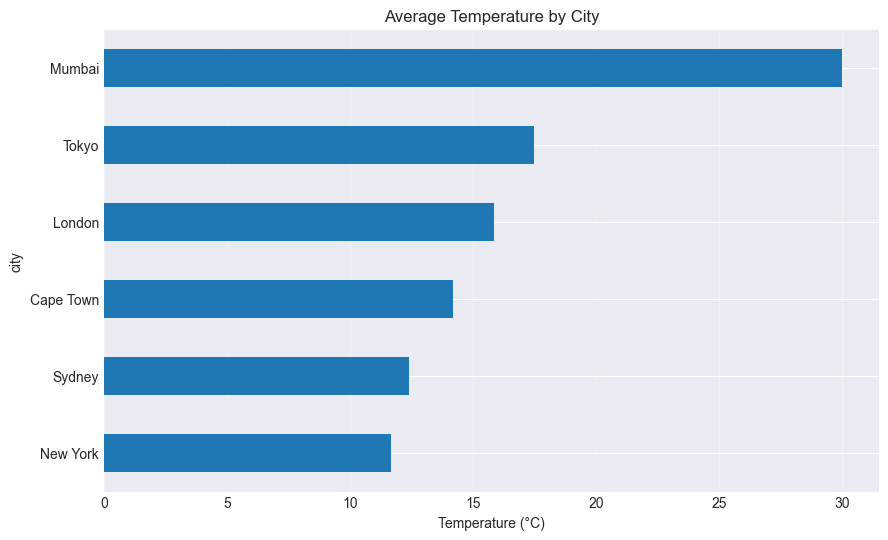

In [11]:
# Temperature by city
city_temps = df.groupby('city')['temperature_c'].mean().sort_values()

plt.figure(figsize=(10, 6))
city_temps.plot(kind='barh')
plt.xlabel('Temperature (°C)')
plt.title('Average Temperature by City')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 4.  Weather conditions distribution

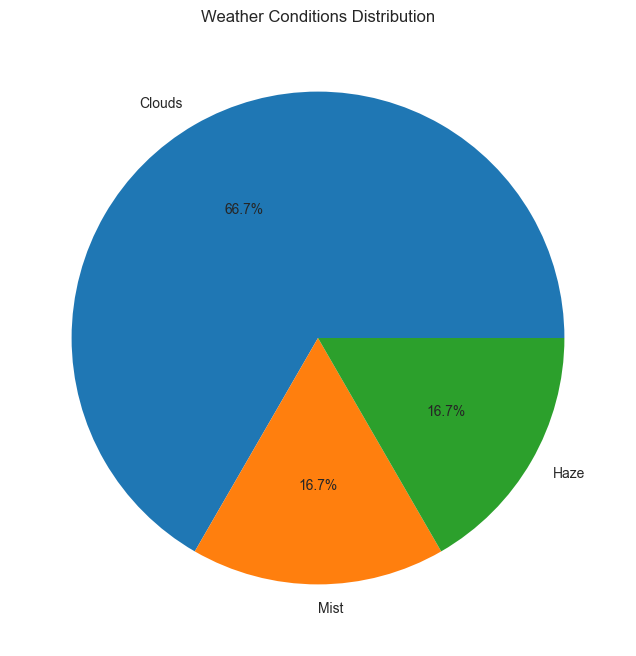

In [12]:
# Count weather conditions
weather_counts = df['weather_main'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%')
plt.title('Weather Conditions Distribution')
plt.show()

### 5. The End!!